# 08 - Cluster Profiling

**Project:** Customer Financial Behavior Analysis for Banking Business Intelligence

Tahap ini bertujuan menganalisis karakteristik setiap cluster yang dihasilkan oleh algoritma K-Means sehingga setiap kelompok pelanggan dapat dipahami dari sudut pandang bisnis.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

# Load clustered dataset
df = pd.read_csv("customer_clustered.csv")

df.head()


,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant,Cluster
0,-1.146873,-1.165862,-1.067993,-0.387886,-0.325044,0.0,-1.790369,-1.123271,-1.165862,-1.067993,-0.847497,-0.981108,1.034871,-1.034872,0.335019,-0.946900,1
1,1.546156,0.414515,-0.319887,0.091887,-0.261130,0.0,0.340547,0.845636,0.414515,-0.319887,1.081289,-0.085078,0.367206,-0.367205,0.335019,0.738472,1
2,1.429068,0.022949,1.041842,-0.387886,-1.905859,0.0,1.473452,0.058073,0.022949,1.041842,0.116896,-0.085078,0.100139,-0.100139,-0.960562,0.100763,1
3,1.136347,0.134582,-1.164659,-0.387886,-0.121680,0.0,-1.056950,1.239417,0.134582,-1.164659,1.563486,-0.085078,0.450664,-0.450664,0.335019,-0.582495,1
4,0.433818,0.939134,-0.330681,-0.387886,0.694788,0.0,-0.015149,1.633198,0.939134,-0.330681,2.045682,-0.085078,0.515576,-0.515576,0.335019,-0.992451,1


Cluster
0    195
1    300
Name: count, dtype: int64


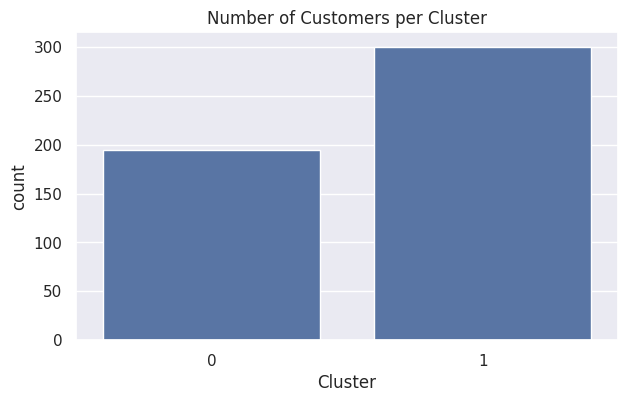

In [ ]:
# Jumlah anggota setiap cluster
cluster_size = df["Cluster"].value_counts().sort_index()

print(cluster_size)

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Cluster")
plt.title("Number of Customers per Cluster")
plt.show()


In [ ]:
# Statistik setiap cluster
cluster_profile = df.groupby("Cluster").mean(numeric_only=True).round(2)

cluster_profile


,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant
Cluster,,,,,,,,,,,,,,,,
0,0.03,0.04,0.06,-0.0,0.06,0.0,-0.12,0.11,0.04,0.06,-0.33,0.87,-1.00,1.00,0.22,-0.02
1,-0.02,-0.03,-0.04,0.0,-0.04,0.0,0.08,-0.07,-0.03,-0.04,0.21,-0.56,0.65,-0.65,-0.14,0.01


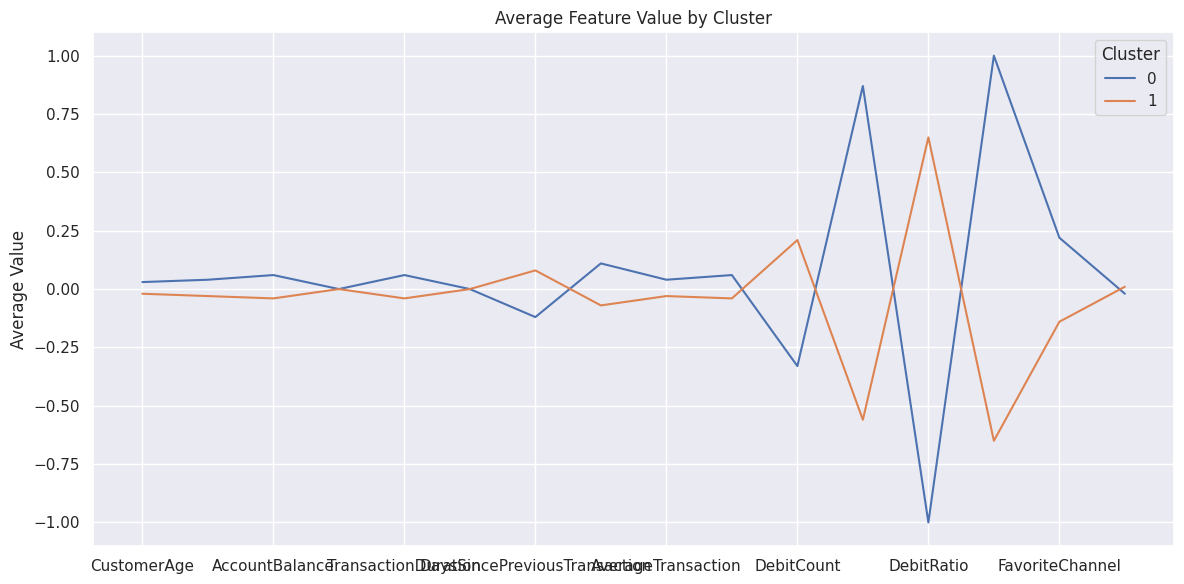

In [ ]:
# Visualisasi rata-rata fitur per cluster
cluster_profile.T.plot(figsize=(12,6))
plt.title("Average Feature Value by Cluster")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


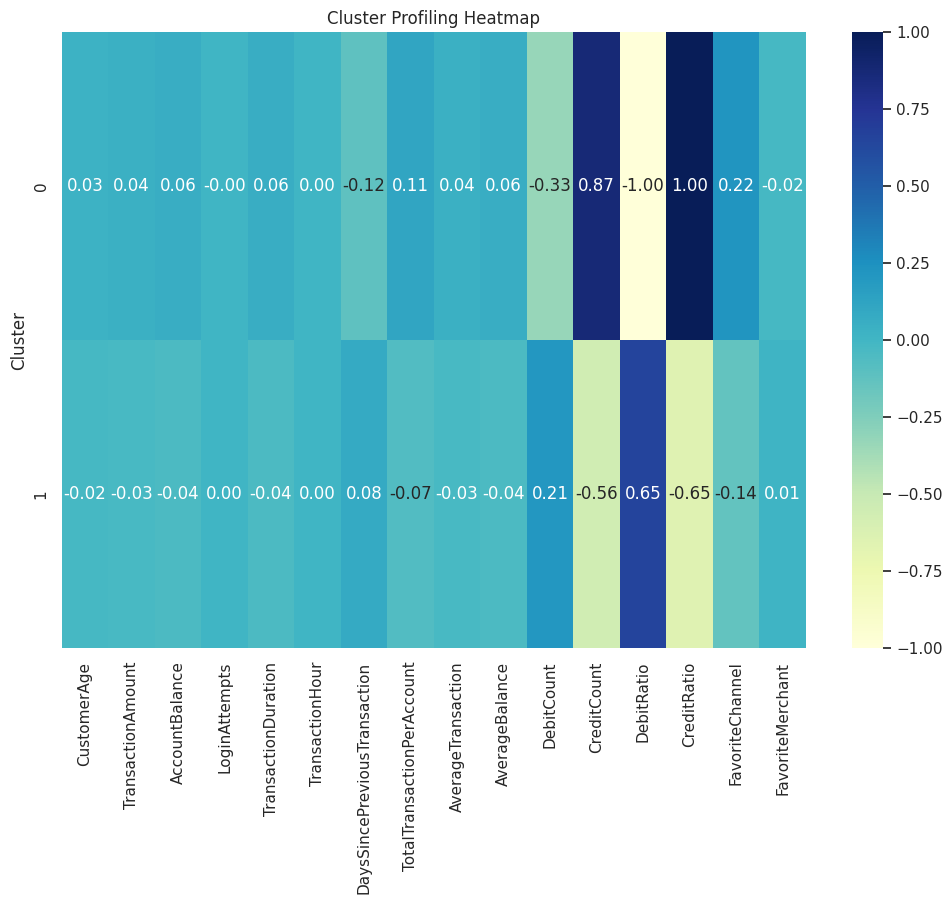

In [ ]:
# Heatmap profil cluster
plt.figure(figsize=(12,8))
sns.heatmap(cluster_profile,
            annot=True,
            cmap="YlGnBu",
            fmt=".2f")

plt.title("Cluster Profiling Heatmap")
plt.show()


In [ ]:
# Ringkasan statistik per cluster
summary = cluster_profile.copy()

summary["ClusterName"] = [
    "High Value Customers",
    "Active Digital Customers",
    "Traditional Banking Customers",
    "Low Activity Customers"
][:len(summary)]

summary


,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant,ClusterName
Cluster,,,,,,,,,,,,,,,,,
0,0.03,0.04,0.06,-0.0,0.06,0.0,-0.12,0.11,0.04,0.06,-0.33,0.87,-1.00,1.00,0.22,-0.02,High Value Customers
1,-0.02,-0.03,-0.04,0.0,-0.04,0.0,0.08,-0.07,-0.03,-0.04,0.21,-0.56,0.65,-0.65,-0.14,0.01,Active Digital Customers


In [ ]:
# Simpan hasil profiling
summary.to_csv("cluster_profile_summary.csv")

print("cluster_profile_summary.csv berhasil disimpan.")


cluster_profile_summary.csv berhasil disimpan.


## Kesimpulan

Tahap Cluster Profiling membantu mengubah hasil clustering menjadi informasi yang mudah dipahami oleh pihak bisnis. Setiap cluster memiliki karakteristik unik yang dapat dijadikan dasar dalam penyusunan strategi pemasaran, layanan pelanggan, dan pengembangan produk perbankan.
